In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

# Paths
BASE = Path("C:/Users/nanig/OneDrive/Desktop/bluestock_mf_capstone")
PROCESSED = BASE / "data/processed"
CHARTS = BASE / "data/processed/charts"
CHARTS.mkdir(exist_ok=True)

# Load data
nav = pd.read_csv(PROCESSED / "clean_nav.csv")
performance = pd.read_csv(PROCESSED / "clean_performance.csv")
fund_master = pd.read_csv(PROCESSED / "clean_fund_master.csv")
benchmark = pd.read_csv(PROCESSED / "clean_benchmark.csv")

# Convert dates
nav['date'] = pd.to_datetime(nav['date'])
nav = nav.sort_values(['amfi_code', 'date'])
benchmark['date'] = pd.to_datetime(benchmark['date'])

print("✅ Data loaded!")
print(f"NAV: {nav.shape}, Performance: {performance.shape}")
print(f"Benchmark indices: {benchmark['index_name'].unique()}")

✅ Data loaded!
NAV: (46000, 3), Performance: (40, 19)
Benchmark indices: <StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str


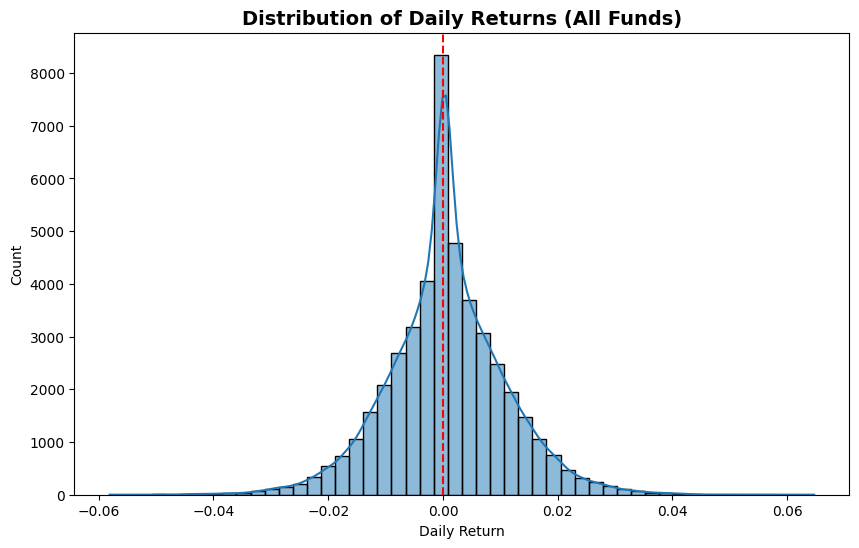

✅ Daily Returns: 45960 records
Mean: 0.0631%
Std Dev: 1.0290%


In [3]:
# === COMPUTE DAILY RETURNS ===
nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

nav_returns = nav[['amfi_code', 'date', 'daily_return']].dropna()

plt.figure(figsize=(10, 6))
sns.histplot(data=nav_returns, x='daily_return', bins=50, kde=True)
plt.title('Distribution of Daily Returns (All Funds)', fontsize=14, fontweight='bold')
plt.xlabel('Daily Return')
plt.axvline(x=0, color='red', linestyle='--')
plt.savefig(CHARTS / 'daily_return_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Daily Returns: {len(nav_returns)} records")
print(f"Mean: {nav_returns['daily_return'].mean():.4%}")
print(f"Std Dev: {nav_returns['daily_return'].std():.4%}")

In [4]:
# === COMPUTE CAGR ===
def calculate_cagr(start_nav, end_nav, days):
    if days <= 0:
        return 0
    return (end_nav / start_nav) ** (365.25 / days) - 1

cagr_data = []
for code in nav['amfi_code'].unique():
    fund_nav = nav[nav['amfi_code'] == code].sort_values('date')
    
    end = fund_nav.iloc[-1]['nav']
    
    # 1yr CAGR
    if len(fund_nav) >= 252:
        start_1yr = fund_nav.iloc[-252]['nav']
        cagr_1yr = calculate_cagr(start_1yr, end, 252)
    else:
        cagr_1yr = None
    
    # 3yr CAGR
    if len(fund_nav) >= 756:
        start_3yr = fund_nav.iloc[-756]['nav']
        cagr_3yr = calculate_cagr(start_3yr, end, 756)
    else:
        cagr_3yr = None
    
    # 5yr CAGR
    if len(fund_nav) >= 1260:
        start_5yr = fund_nav.iloc[-1260]['nav']
        cagr_5yr = calculate_cagr(start_5yr, end, 1260)
    else:
        cagr_5yr = None
    
    cagr_data.append({
        'amfi_code': code,
        'cagr_1yr': cagr_1yr,
        'cagr_3yr': cagr_3yr,
        'cagr_5yr': cagr_5yr
    })

cagr_df = pd.DataFrame(cagr_data)
print("✅ CAGR Calculated!")
print(cagr_df.head(10))

✅ CAGR Calculated!
   amfi_code  cagr_1yr  cagr_3yr cagr_5yr
0     100016 -0.047552 -0.000458     None
1     100025  0.036464  0.067568     None
2     100033  0.760550  0.522236     None
3     101206  0.715123  0.504098     None
4     101207 -0.331283 -0.038845     None
5     101208  0.100858  0.089257     None
6     102885  0.276095  0.263633     None
7     102886 -0.185857 -0.026447     None
8     102887  0.189637  0.392489     None
9     118632  0.330508  0.272502     None


In [5]:
# === COMPUTE SHARPE & SORTINO RATIO ===
RISK_FREE_RATE = 0.065
TRADING_DAYS = 252

sharpe_data = []
for code in nav['amfi_code'].unique():
    returns = nav[nav['amfi_code'] == code]['daily_return'].dropna()
    
    if len(returns) > 0:
        mean_return = returns.mean() * TRADING_DAYS
        std_return = returns.std() * np.sqrt(TRADING_DAYS)
        
        if std_return > 0:
            sharpe = (mean_return - RISK_FREE_RATE) / std_return
        else:
            sharpe = None
        
        neg_returns = returns[returns < 0]
        downside_std = neg_returns.std() * np.sqrt(TRADING_DAYS) if len(neg_returns) > 0 else 0
        
        if downside_std > 0:
            sortino = (mean_return - RISK_FREE_RATE) / downside_std
        else:
            sortino = None
        
        sharpe_data.append({
            'amfi_code': code,
            'sharpe_ratio': sharpe,
            'sortino_ratio': sortino,
            'annualized_return': mean_return,
            'volatility': std_return
        })

sharpe_df = pd.DataFrame(sharpe_data)
print("✅ Sharpe & Sortino Calculated!")
print(sharpe_df.nlargest(10, 'sharpe_ratio')[['amfi_code', 'sharpe_ratio', 'sortino_ratio']])

✅ Sharpe & Sortino Calculated!
    amfi_code  sharpe_ratio  sortino_ratio
34     148567      1.448291       2.385644
30     120843      1.306744       2.364320
36     148569      1.234930       2.146914
19     119551      1.208267       2.140267
25     120505      1.180101       2.029353
38     149323      1.132122       1.875101
2      100033      1.093699       1.829134
9      118632      1.081659       1.850133
3      101206      1.027213       1.799563
24     120504      1.026524       1.805294


In [8]:

        # === COMPUTE ALPHA & BETA ===
nifty = benchmark[benchmark['index_name'] == 'NIFTY100'].copy()
nifty = nifty.sort_values('date')
nifty['benchmark_return'] = nifty['close_value'].pct_change()

alpha_beta_data = []

for code in nav['amfi_code'].unique():
    fund_nav = nav[nav['amfi_code'] == code].copy()
    fund_nav = fund_nav.sort_values('date')
    fund_nav['fund_return'] = fund_nav['nav'].pct_change()
    
    merged = fund_nav.merge(nifty[['date', 'benchmark_return']], on='date', how='inner')
    merged = merged.dropna()
    
    if len(merged) > 30:
        slope, intercept, r_value, p_value, std_err = stats.linregress(
            merged['benchmark_return'], merged['fund_return']
        )
        
        alpha = intercept * 252
        beta = slope
        
        alpha_beta_data.append({
            'amfi_code': code,
            'alpha': alpha,
            'beta': beta,
            'r_squared': r_value ** 2
        })

alpha_beta_df = pd.DataFrame(alpha_beta_data)
print("✅ Alpha & Beta Calculated!")
print(alpha_beta_df.nlargest(10, 'alpha')[['amfi_code', 'alpha', 'beta']])

✅ Alpha & Beta Calculated!
    amfi_code     alpha      beta
21     119598  0.303370 -0.023196
39     149324  0.300579  0.011455
25     120505  0.292636  0.000549
36     148569  0.282704  0.018134
30     120843  0.273305 -0.022830
2      100033  0.271954  0.005104
34     148567  0.269838  0.023684
38     149323  0.265986 -0.002523
16     119094  0.260767 -0.066265
19     119551  0.232010 -0.031751


In [9]:
# === COMPUTE MAX DRAWDOWN ===
max_dd_data = []

for code in nav['amfi_code'].unique():
    fund_nav = nav[nav['amfi_code'] == code].sort_values('date')
    nav_values = fund_nav['nav'].values
    
    running_max = np.maximum.accumulate(nav_values)
    drawdowns = (nav_values - running_max) / running_max
    
    max_dd = drawdowns.min()
    
    max_dd_data.append({
        'amfi_code': code,
        'max_drawdown': max_dd
    })

max_dd_df = pd.DataFrame(max_dd_data)
print("✅ Max Drawdown Calculated!")
print(max_dd_df.nsmallest(10, 'max_drawdown'))

✅ Max Drawdown Calculated!
    amfi_code  max_drawdown
22     119599     -0.525742
17     119095     -0.516778
4      101207     -0.354469
39     149324     -0.311719
21     119598     -0.287060
7      102886     -0.280011
0      100016     -0.247344
29     120842     -0.240035
11     118634     -0.233449
15     119093     -0.217514


In [10]:
# === CREATE FUND SCORECARD ===
scorecard = fund_master[['amfi_code', 'scheme_name', 'fund_house', 'category', 'expense_ratio_pct']].copy()

scorecard = scorecard.merge(cagr_df, on='amfi_code', how='left')
scorecard = scorecard.merge(sharpe_df[['amfi_code', 'sharpe_ratio', 'sortino_ratio', 'volatility']], on='amfi_code', how='left')
scorecard = scorecard.merge(alpha_beta_df, on='amfi_code', how='left')
scorecard = scorecard.merge(max_dd_df, on='amfi_code', how='left')

# Rank each metric
scorecard['cagr_rank'] = scorecard['cagr_3yr'].rank(ascending=False)
scorecard['sharpe_rank'] = scorecard['sharpe_ratio'].rank(ascending=False)
scorecard['alpha_rank'] = scorecard['alpha'].rank(ascending=False)
scorecard['er_rank'] = scorecard['expense_ratio_pct'].rank(ascending=True)
scorecard['dd_rank'] = scorecard['max_drawdown'].rank(ascending=False)

# Composite score
scorecard['fund_score'] = (
    scorecard['cagr_rank'] * 0.30 +
    scorecard['sharpe_rank'] * 0.25 +
    scorecard['alpha_rank'] * 0.20 +
    scorecard['er_rank'] * 0.15 +
    scorecard['dd_rank'] * 0.10
)

# Normalize to 0-100
max_score = scorecard['fund_score'].max()
scorecard['fund_score'] = 100 - ((scorecard['fund_score'] / max_score) * 100)

scorecard = scorecard.sort_values('fund_score', ascending=False)
scorecard.to_csv(PROCESSED / 'fund_scorecard.csv', index=False)

print("✅ Fund Scorecard Created!")
print(scorecard.head(10)[['scheme_name', 'fund_score', 'cagr_3yr', 'sharpe_ratio', 'alpha']])

✅ Fund Scorecard Created!
                                          scheme_name  fund_score  cagr_3yr  \
34      Mirae Asset Large Cap Fund - Regular - Growth   80.042164  0.483579   
7   HDFC Mid-Cap Opportunities Fund - Regular - Gr...   77.231202  0.522236   
12           ICICI Pru Midcap Fund - Regular - Growth   77.231202  0.466052   
22             Kotak Flexicap Fund - Regular - Growth   74.420239  0.392471   
11          ICICI Pru Bluechip Fund - Direct - Growth   72.171469  0.436173   
26                Axis Midcap Fund - Regular - Growth   71.328180  0.562635   
0           SBI Bluechip Fund - Regular Plan - Growth   67.182010  0.425768   
28      ABSL Frontline Equity Fund - Regular - Growth   66.479269  0.504098   
2          SBI Small Cap Fund - Regular Plan - Growth   64.722417  0.427175   
36      Mirae Asset Tax Saver Fund - Regular - Growth   63.387210  0.354970   

    sharpe_ratio     alpha  
34      1.448291  0.269838  
7       1.093699  0.271954  
12      1.180101 

In [11]:
# Save alpha_beta.csv
alpha_beta_df.to_csv(PROCESSED / 'alpha_beta.csv', index=False)
print("✅ alpha_beta.csv saved!")


✅ alpha_beta.csv saved!


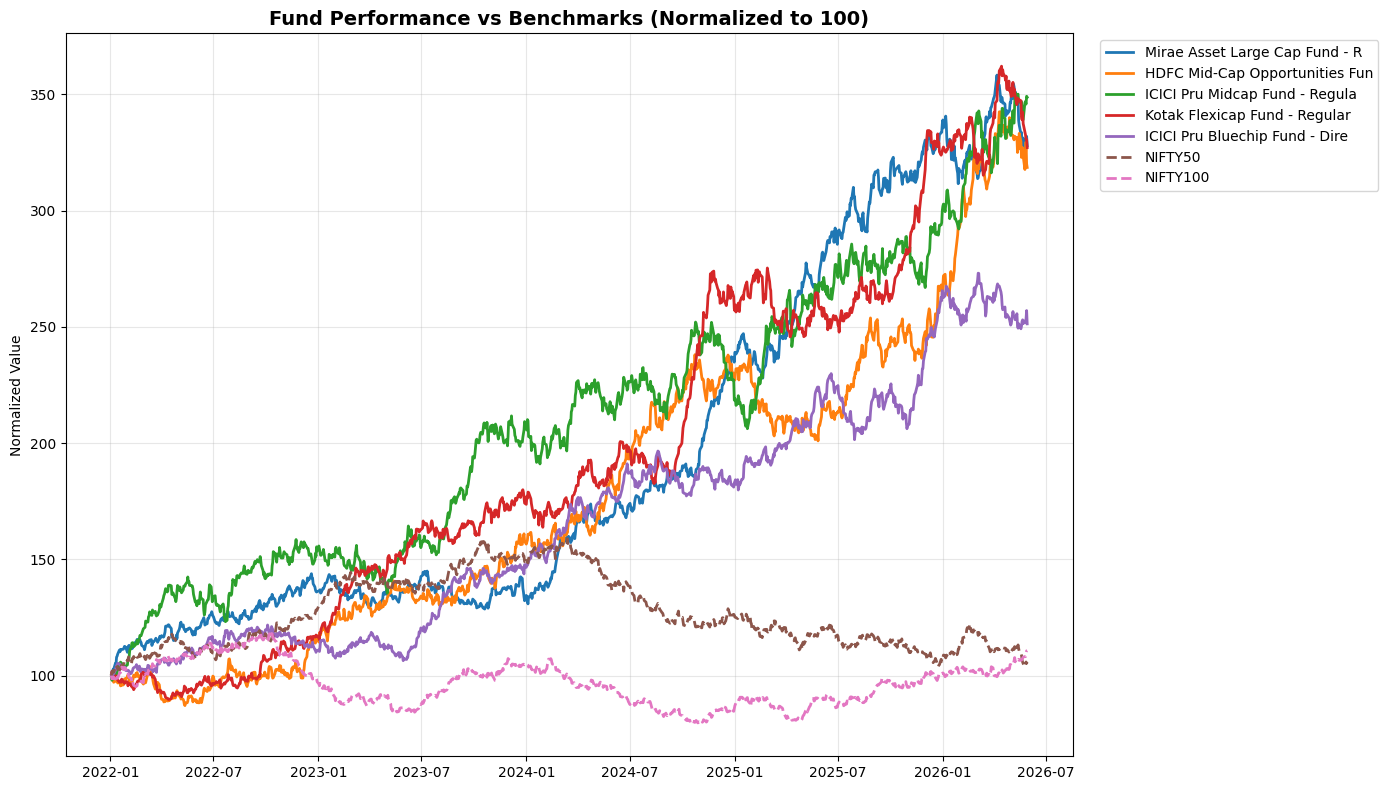

✅ Benchmark chart saved!


In [12]:
# === BENCHMARK COMPARISON CHART ===
top5_codes = scorecard.head(5)['amfi_code'].values

plt.figure(figsize=(14, 8))

# Plot top 5 funds
for code in top5_codes:
    fund_nav = nav[nav['amfi_code'] == code].sort_values('date')
    normalized = (fund_nav['nav'] / fund_nav['nav'].iloc[0]) * 100
    name = fund_master[fund_master['amfi_code'] == code]['scheme_name'].values[0][:30]
    plt.plot(fund_nav['date'], normalized, label=name, linewidth=2)

# Plot benchmarks
for bench_name in ['NIFTY50', 'NIFTY100']:
    bench_data = benchmark[benchmark['index_name'] == bench_name].sort_values('date')
    if len(bench_data) > 0:
        normalized = (bench_data['close_value'] / bench_data['close_value'].iloc[0]) * 100
        plt.plot(bench_data['date'], normalized, label=bench_name, linewidth=2, linestyle='--')

plt.title('Fund Performance vs Benchmarks (Normalized to 100)', fontsize=14, fontweight='bold')
plt.ylabel('Normalized Value')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(CHARTS / 'benchmark_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Benchmark chart saved!")

In [13]:
# === COMPUTE TRACKING ERROR ===
tracking_error_data = []

for code in nav['amfi_code'].unique():
    fund_nav = nav[nav['amfi_code'] == code].copy()
    fund_nav = fund_nav.sort_values('date')
    fund_nav['fund_return'] = fund_nav['nav'].pct_change()
    
    merged = fund_nav.merge(nifty[['date', 'benchmark_return']], on='date', how='inner')
    merged = merged.dropna()
    
    if len(merged) > 30:
        tracking_error = merged['fund_return'] - merged['benchmark_return']
        te = tracking_error.std() * np.sqrt(252)
        
        tracking_error_data.append({
            'amfi_code': code,
            'tracking_error': te
        })

te_df = pd.DataFrame(tracking_error_data)
scorecard = scorecard.merge(te_df, on='amfi_code', how='left')
scorecard.to_csv(PROCESSED / 'fund_scorecard.csv', index=False)

print("✅ Tracking Error Calculated!")
print(te_df.nsmallest(10, 'tracking_error'))

✅ Tracking Error Calculated!
    amfi_code  tracking_error
5      101208        0.128957
27     120507        0.129044
31     120844        0.129046
1      100025        0.134535
13     118636        0.134758
18     119120        0.135646
12     118635        0.183076
28     120841        0.183119
6      102885        0.183680
15     119093        0.187900


In [14]:
# === SUMMARY ===
print("=" * 60)
print("DAY 4: PERFORMANCE ANALYTICS COMPLETE!")
print("=" * 60)

print("\n📊 KEY FINDINGS:")

# Top by Sharpe
top_sharpe = sharpe_df.nlargest(5, 'sharpe_ratio')
print(f"\n🏆 Top Sharpe Ratio:")
for _, row in top_sharpe.iterrows():
    name = fund_master[fund_master['amfi_code'] == row['amfi_code']]['scheme_name'].values[0][:35]
    print(f"   {name}: {row['sharpe_ratio']:.2f}")

# Top by Alpha
top_alpha = alpha_beta_df.nlargest(5, 'alpha')
print(f"\n📈 Top Alpha:")
for _, row in top_alpha.iterrows():
    name = fund_master[fund_master['amfi_code'] == row['amfi_code']]['scheme_name'].values[0][:35]
    print(f"   {name}: {row['alpha']:.2%}")

# Worst Max Drawdown
worst_dd = max_dd_df.nsmallest(5, 'max_drawdown')
print(f"\n⚠️ Worst Max Drawdown:")
for _, row in worst_dd.iterrows():
    name = fund_master[fund_master['amfi_code'] == row['amfi_code']]['scheme_name'].values[0][:35]
    print(f"   {name}: {row['max_drawdown']:.2%}")

print("\n📁 FILES CREATED:")
print(f"   ✅ fund_scorecard.csv")
print(f"   ✅ alpha_beta.csv")
print(f"   ✅ benchmark_comparison.png")
print(f"   ✅ daily_return_dist.png")

DAY 4: PERFORMANCE ANALYTICS COMPLETE!

📊 KEY FINDINGS:

🏆 Top Sharpe Ratio:
   Mirae Asset Large Cap Fund - Regula: 1.45
   Kotak Flexicap Fund - Regular - Gro: 1.31
   Mirae Asset Tax Saver Fund - Regula: 1.23
   SBI Bluechip Fund - Regular Plan - : 1.21
   ICICI Pru Midcap Fund - Regular - G: 1.18

📈 Top Alpha:
   SBI Small Cap Fund - Regular Plan -: 30.34%
   DSP Small Cap Fund - Regular - Grow: 30.06%
   ICICI Pru Midcap Fund - Regular - G: 29.26%
   Mirae Asset Tax Saver Fund - Regula: 28.27%
   Kotak Flexicap Fund - Regular - Gro: 27.33%

⚠️ Worst Max Drawdown:
   SBI Small Cap Fund - Direct Plan - : -52.57%
   Axis Small Cap Fund - Regular - Gro: -51.68%
   ABSL Small Cap Fund - Regular - Gro: -35.45%
   DSP Small Cap Fund - Regular - Grow: -31.17%
   SBI Small Cap Fund - Regular Plan -: -28.71%

📁 FILES CREATED:
   ✅ fund_scorecard.csv
   ✅ alpha_beta.csv
   ✅ benchmark_comparison.png
   ✅ daily_return_dist.png
